Extracting channel 1 out of 1 channels, 16-bit depth


<ipython-input-3-e3ad927c01f5>:55: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  data = np.fromstring(sdata, dtype=typ)
<ipython-input-3-e3ad927c01f5>:62: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  outwav.writeframes(ch_data.tostring())
<ipython-input-3-e3ad927c01f5>:70: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  ys = np.fromstring(wavFrames, dtype=np.int16)


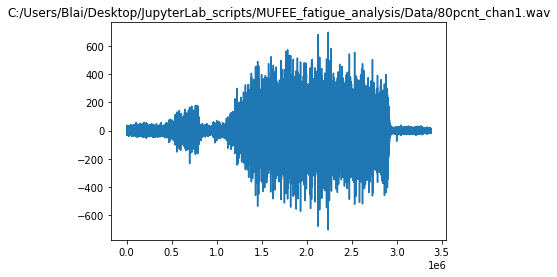

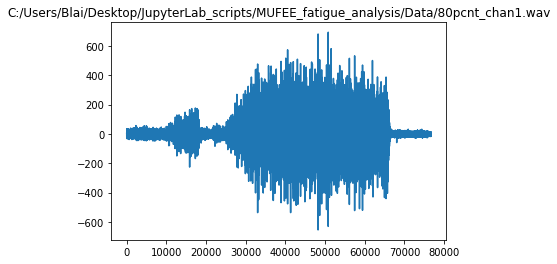

In [3]:
"""
Script to convert WAV spikerbox files to 1000Hz excel files

Before launching the script you need to (just the first time):
    
    run on the console: pip install pydub
    
    restart kernel
"""

from tkinter import filedialog
from tkinter import *
import os 
from pydub import AudioSegment as am
import wave
from wave import open as open_wave
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


#Opens a GUI window to find and select a file
def GUI_file_selection (start_folder):
    root = Tk()
    root.lift()
    filename_path = filedialog.askopenfilename(initialdir=start_folder, title="Select a file")
    root.withdraw()
    return filename_path


def filename_and_path_splitter (filename_path):
    split_position = filename_path.rfind('/')
    path = filename_path[0:split_position+1]
    filename = filename_path[split_position+1:]
    return path, filename

def save_wav_channel(fn, wav, channel):
    '''
    Take Wave_read object as an input and save one of its
    channels into a separate .wav file.
    '''
    # Read data
    nch   = wav.getnchannels()
    depth = wav.getsampwidth()
    wav.setpos(0)
    sdata = wav.readframes(wav.getnframes())

    # Extract channel data (24-bit data not supported)
    typ = { 1: np.uint8, 2: np.uint16, 4: np.uint32 }.get(depth)
    if not typ:
        raise ValueError("sample width {} not supported".format(depth))
    if channel >= nch:
        raise ValueError("cannot extract channel {} out of {}".format(channel+1, nch))
    print ("Extracting channel {} out of {} channels, {}-bit depth".format(channel+1, nch, depth*8))
    data = np.fromstring(sdata, dtype=typ)
    ch_data = data[channel::nch]

    # Save channel to a separate file
    outwav = wave.open(fn, 'wb')
    outwav.setparams(wav.getparams())
    outwav.setnchannels(1)
    outwav.writeframes(ch_data.tostring())
    outwav.close()

def transform_and_plot_wav (file):
    waveFile = open_wave(file,'rb')
    # nChann=waveFile.getnchannels()
    nframes = waveFile.getnframes()
    wavFrames = waveFile.readframes(nframes)
    ys = np.fromstring(wavFrames, dtype=np.int16)
    plt.figure()
    plt.plot(ys)
    plt.title(file)
    waveFile.close()
    return ys


#MAIN
filename_path = GUI_file_selection ('C/:')
path, filename = filename_and_path_splitter (filename_path)

#transform multichannel wav to single channel wav
wav = wave.open(filename_path)
chan_n = wav.getnchannels()
wav_file_list = []
if chan_n>0:
    chan1 = save_wav_channel(path+filename.split('.')[0]+'_chan1.wav', wav, 0)
    wav_file_list.append(path+filename.split('.')[0]+'_chan1.wav')
if chan_n>1:
    chan2 = save_wav_channel(path+filename.split('.')[0]+'_chan2.wav', wav, 1)
    wav_file_list.append(path+filename.split('.')[0]+'_chan2.wav')
if chan_n>2:
    chan3 = save_wav_channel(path+filename.split('.')[0]+'_chan3.wav', wav, 2)
    wav_file_list.append(path+filename.split('.')[0]+'_chan3.wav')
if chan_n>3:
    chan4 = save_wav_channel(path+filename.split('.')[0]+'_chan4.wav', wav, 3)
    wav_file_list.append(path+filename.split('.')[0]+'_chan4.wav')
wav.close()
#downsample to 1000Hz
chan_dict={}
for file in wav_file_list:
    original_wave = transform_and_plot_wav(file)
    sound = am.from_file(file, format='wav', frame_rate=44100)
    sound = sound.set_frame_rate(1000)
    sound.export(file, format='wav')
    one_khz_wave = transform_and_plot_wav(file)
    chan_dict[file[-9:-4]] = one_khz_wave

df = pd.DataFrame (chan_dict)
df.to_excel(path+filename.split('.')[0]+'.xlsx', header = True, index= False)




